**k-mode clustering**

In [1]:
import numpy as np
import pandas as pd

data = np.array([
  ['A', 'B', 'C'],
  ['B', 'C', 'A'],
  ['C', 'A', 'B'],
  ['A', 'C', 'B'],
  ['A', 'A', 'B']
])

In [2]:
k = 3
np.random.seed(0)
modes = data[np.random.choice(data.shape[0], k, replace=False)]

In [3]:
clusters = np.zeros(data.shape[0], dtype=int)

for _ in range(10):
  for i, points in enumerate(data):
    distance = [np.sum(points != mode) for mode in modes]
    clusters[i] = np.argmin(distance)

In [4]:
for j in range(k):
  if np.any(clusters == j):
    modes[j] = pd.DataFrame(data[clusters == j]).mode().iloc[0].values

In [5]:
print("cluster assignment: ", clusters)
print("cluster mode: ", modes)

cluster assignment:  [1 2 0 0 0]
cluster mode:  [['A' 'A' 'B']
 ['A' 'B' 'C']
 ['B' 'C' 'A']]


**Kmodes library**

Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 1, iteration: 1/100, moves: 0, cost: 7.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 2, iteration: 1/100, moves: 0, cost: 7.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 3, iteration: 1/100, moves: 0, cost: 7.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 4, iteration: 1/100, moves: 0, cost: 7.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 5, iteration: 1/100, moves: 0, cost: 7.0
Best run was number 1
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 1, iteration: 1/100, moves: 1, cost: 4.0
Run 1, iteration: 2/100, moves: 0, cost: 4.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 2, iteration: 1/100, moves: 2, cost: 4.0
Run 2, iteration: 2/100, moves: 0, cost: 4.0
Init: initial

Text(0.5, 1.0, 'Elbow curve')

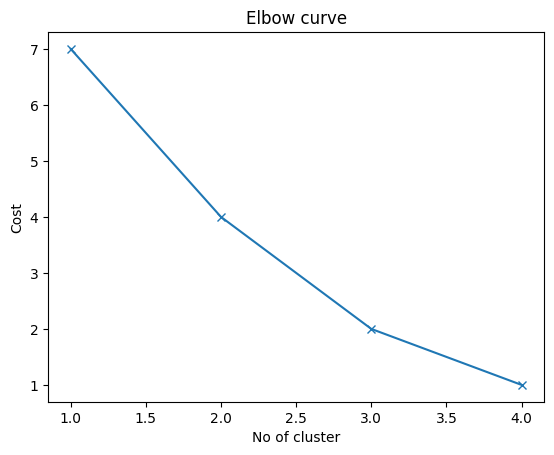

In [8]:
from kmodes.kmodes import KModes
import matplotlib.pyplot as plt
%matplotlib inline

cost = []
k = range(1, 5)
for i in list(k):
  kmode = KModes(n_clusters=i, init='random', n_init=5, verbose=1)
  kmode.fit_predict(data)
  cost.append(kmode.cost_)

plt.plot(k, cost, 'x-')
plt.xlabel('No of cluster')
plt.ylabel('Cost')
plt.title("Elbow curve")

In [9]:
kmode = KModes(n_clusters=2, init = "random", n_init = 5, verbose=1)
clusters = kmode.fit_predict(data)
clusters

Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 1, iteration: 1/100, moves: 0, cost: 5.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 2, iteration: 1/100, moves: 0, cost: 5.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 3, iteration: 1/100, moves: 0, cost: 4.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 4, iteration: 1/100, moves: 1, cost: 4.0
Run 4, iteration: 2/100, moves: 0, cost: 4.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 5, iteration: 1/100, moves: 0, cost: 4.0
Best run was number 3


array([1, 0, 1, 1, 1], dtype=uint16)